In [140]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [141]:
# veriyi oku, bozuk satırları atladı
df = pd.read_csv('airbnb_istanbul.csv', encoding='utf-8', on_bad_lines='skip')

In [142]:
 df.head() 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license;;
0,1342043490398914341,ĞÑ‚Ğ´ĞµĞ»ÑŒĞ½Ğ°Ñ ĞºĞ²Ğ°Ñ€Ñ‚Ğ¸Ñ€Ğ° Ğ½Ğ° Ğ¤Ğ°Ñ...,444141348.00,Diana,NaN,Fatih,41.03,28.95,Entire home/apt,2290.00,5.00,4.00,2025-09-19,0.58,2.00,180.00,4.00,A28394518;;
1,1342082318675744621,Blue standart 7,304448264.00,Harun & Emre,NaN,Beyoglu,41.04,28.98,Private room,1101.00,7.00,4.00,2025-09-02,0.67,7.00,328.00,4.00,12-9738;;
2,1342210705450176162,Central Located Stylish Flat,380165223.00,Merve,NaN,Beyoglu,41.03,28.98,Entire home/apt,3430.00,2.00,26.00,2025-08-19,3.44,13.00,327.00,26.00,2022-34-2652;;
3,1342423666721201645,Grand Aura NiÅŸantaÅŸÄ± (3+1 buyuk daire),211277594.00,Eda,NaN,Sisli,41.05,28.99,Entire home/apt,3178.00,100.00,1.00,2025-04-07,0.17,5.00,364.00,1.00,;;
4,1342517182143105214,GeniÅŸ bir oda,211277594.00,Eda,NaN,Sisli,41.06,28.99,Private room,1860.00,1.00,2.00,2025-09-08,1.13,5.00,364.00,2.00,Non-real estate listing;;


In [143]:
# sadece kullanacagım kolonları aldım
kolonlar = [
    'neighbourhood',
    'latitude',
    'longitude',
    'room_type',
    'price',
    'minimum_nights',
    'number_of_reviews',
    'availability_365'
]

df = df[kolonlar]
df.shape

(30145, 8)

In [144]:
df.isnull().sum()

neighbourhood        3190
latitude             3190
longitude            3190
room_type            3190
price                7562
minimum_nights       3190
number_of_reviews    3190
availability_365     3190
dtype: int64

In [145]:
len(df)

30145

In [146]:
# fiyatı boş olan degerleri at
df = df.dropna(subset=['price'])
len(df)

22583

In [147]:
df.isnull().sum()

neighbourhood        0
latitude             0
longitude            0
room_type            0
price                0
minimum_nights       0
number_of_reviews    0
availability_365     0
dtype: int64

In [148]:
df.dtypes

neighbourhood         object
latitude             float64
longitude            float64
room_type             object
price                float64
minimum_nights       float64
number_of_reviews    float64
availability_365     float64
dtype: object

In [149]:
pd.options.display.float_format = '{:.2f}'.format
df.describe()

,latitude,longitude,price,minimum_nights,number_of_reviews,availability_365
count,22583.00,22583.00,22583.00,22583.00,22583.00,22583.00
mean,41.03,28.97,5197.53,49.09,19.47,300.90
std,0.05,0.15,56329.37,56.11,44.86,91.25
min,40.82,28.01,80.00,1.00,0.00,0.00
25%,41.01,28.96,1630.00,1.00,0.00,269.00
50%,41.03,28.98,2514.00,5.00,2.00,353.00
75%,41.05,29.00,4036.00,100.00,17.00,365.00
max,41.48,29.87,4437598.00,999.00,1653.00,365.00


In [150]:
# fiyat dağılımının üst sınırlarını belirlemek için yüzdelik dilimler
df['price'].quantile([0.90, 0.95, 0.99])

0.90    6714.20
0.95    9567.80
0.99   25584.72
Name: price, dtype: float64

In [151]:
# aşırı değerleri temizle
df = df[df['price'] <= 25000]
df = df[df['minimum_nights'] <= 365]
len(df)

22347

In [152]:
df['price'].max()

25000.0

In [153]:
# en pahalı 15 ilçe - medyan fiyata göre
ilce_fiyat = df.groupby('neighbourhood')['price'].median().sort_values(ascending=False).head(15)
print(ilce_fiyat)

neighbourhood
Silivri         7166.00
Sile            4239.00
Catalca         4229.00
Adalar          3843.00
Zeytinburnu     3796.50
Sariyer         3423.00
Buyukcekmece    3200.00
Gaziosmanpasa   3010.50
Beylikduzu      3004.50
Bagcilar        2911.00
Basaksehir      2900.00
Sisli           2860.00
Atasehir        2768.00
Besiktas        2756.00
Bayrampasa      2651.00
Name: price, dtype: float64


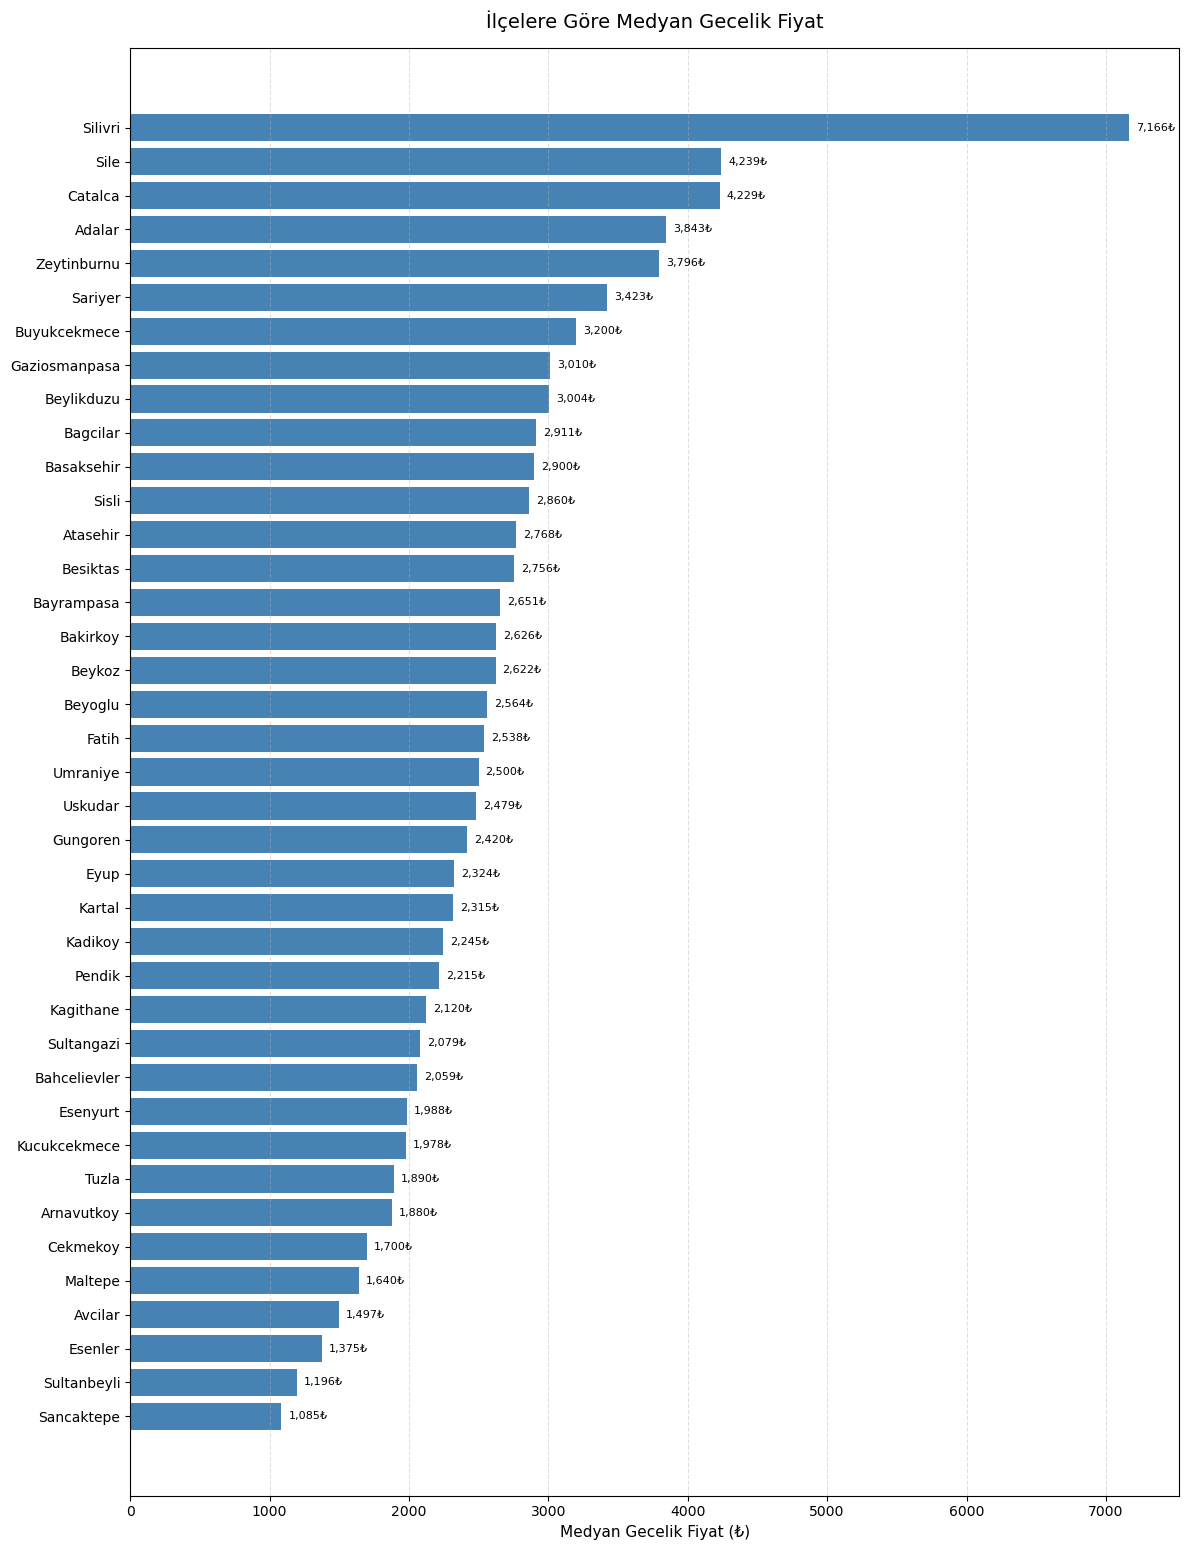

In [154]:
ilce_fiyat = df.groupby('neighbourhood')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(12, len(ilce_fiyat) * 0.4))
bars = plt.barh(ilce_fiyat.index, ilce_fiyat.values, color='steelblue', edgecolor='none')

# her barın yanına fiyatı yaz
for bar, value in zip(bars, ilce_fiyat.values):
    plt.text(value + 50, bar.get_y() + bar.get_height()/2, 
             f'{value:,.0f}₺', va='center', fontsize=8)

plt.title('İlçelere Göre Medyan Gecelik Fiyat', fontsize=14, pad=15)
plt.xlabel('Medyan Gecelik Fiyat (₺)', fontsize=11)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [155]:
# bölge bazında ilan sayısı
bolge_ilan = df['neighbourhood'].value_counts()
print(bolge_ilan)

neighbourhood
Beyoglu          6210
Fatih            3029
Sisli            2910
Kadikoy          1470
Besiktas         1258
Esenyurt          918
Bahcelievler      661
Kagithane         536
Uskudar           520
Bagcilar          449
Atasehir          369
Maltepe           286
Basaksehir        281
Sile              266
Avcilar           255
Umraniye          251
Bakirkoy          247
Kucukcekmece      232
Beylikduzu        216
Arnavutkoy        215
Adalar            209
Pendik            202
Sariyer           185
Kartal            172
Eyup              168
Buyukcekmece      129
Zeytinburnu       122
Beykoz            118
Silivri            84
Tuzla              77
Gaziosmanpasa      74
Cekmekoy           55
Gungoren           43
Catalca            31
Bayrampasa         27
Sancaktepe         22
Esenler            20
Sultangazi         17
Sultanbeyli        13
Name: count, dtype: int64


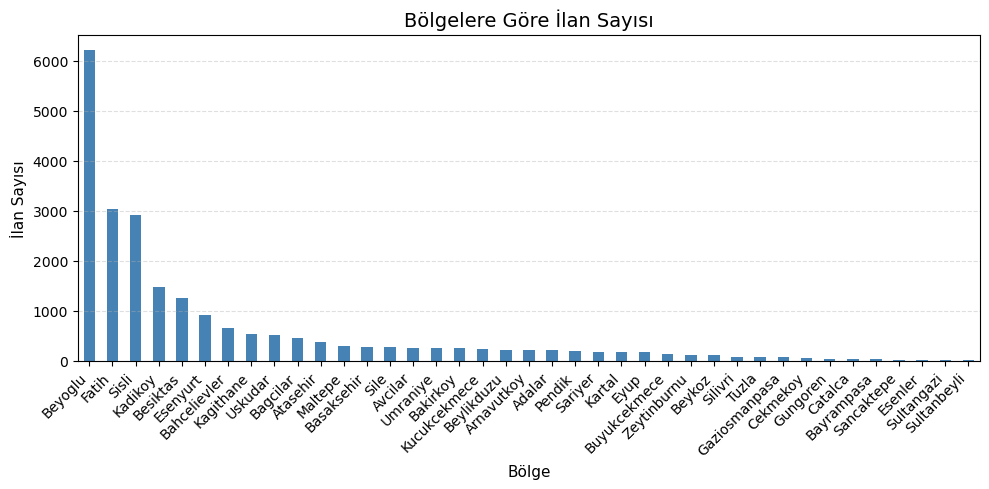

In [156]:
plt.figure(figsize=(10, 5))
bolge_ilan.plot(kind='bar', color='steelblue', edgecolor='none')

plt.title('Bölgelere Göre İlan Sayısı', fontsize=14)
plt.xlabel('Bölge', fontsize=11)
plt.ylabel('İlan Sayısı', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [157]:
# en çok tercih edilen ilçeler - yorum sayısına göre
ilce_tercih = df.groupby('neighbourhood')['number_of_reviews'].sum().sort_values(ascending=False).head(15)
print(ilce_tercih)

neighbourhood
Beyoglu      208549.00
Fatih         85175.00
Kadikoy       37854.00
Sisli         33326.00
Besiktas      17576.00
Adalar         7241.00
Uskudar        4635.00
Esenyurt       4605.00
Bakirkoy       3901.00
Sile           3522.00
Bagcilar       3516.00
Kagithane      3220.00
Maltepe        2824.00
Atasehir       2699.00
Arnavutkoy     2348.00
Name: number_of_reviews, dtype: float64


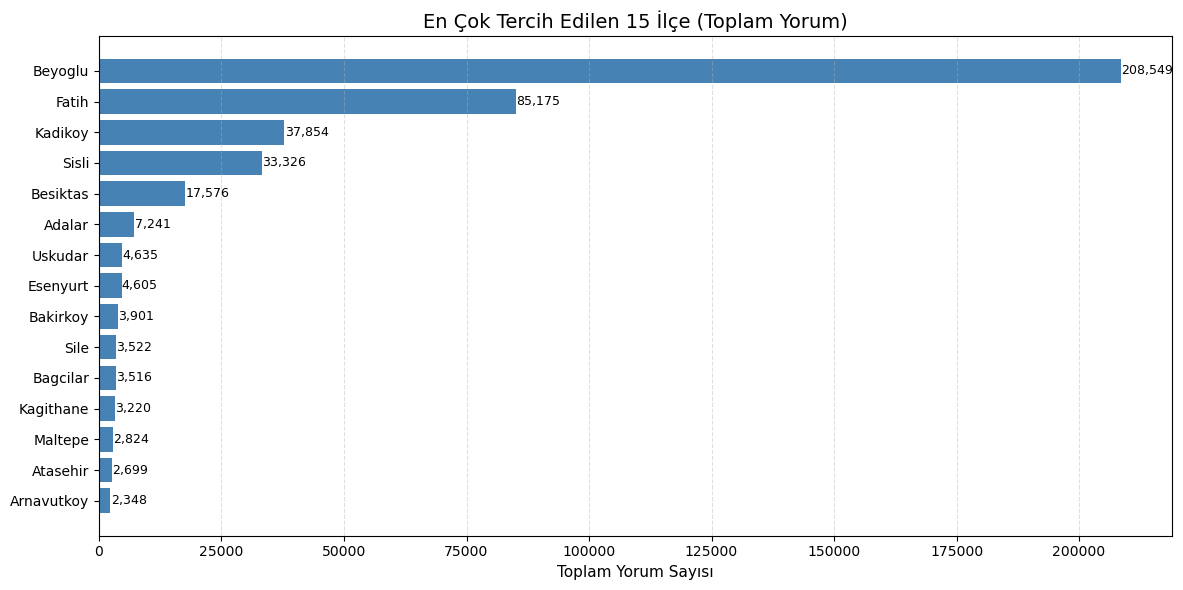

In [158]:
plt.figure(figsize=(12, 6))
bars = plt.barh(ilce_tercih.index, ilce_tercih.values, color='steelblue', edgecolor='none')

for bar, value in zip(bars, ilce_tercih.values):
    plt.text(value + 50, bar.get_y() + bar.get_height()/2,
             f'{value:,.0f}', va='center', fontsize=9)

plt.title('En Çok Tercih Edilen 15 İlçe (Toplam Yorum)', fontsize=14)
plt.xlabel('Toplam Yorum Sayısı', fontsize=11)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

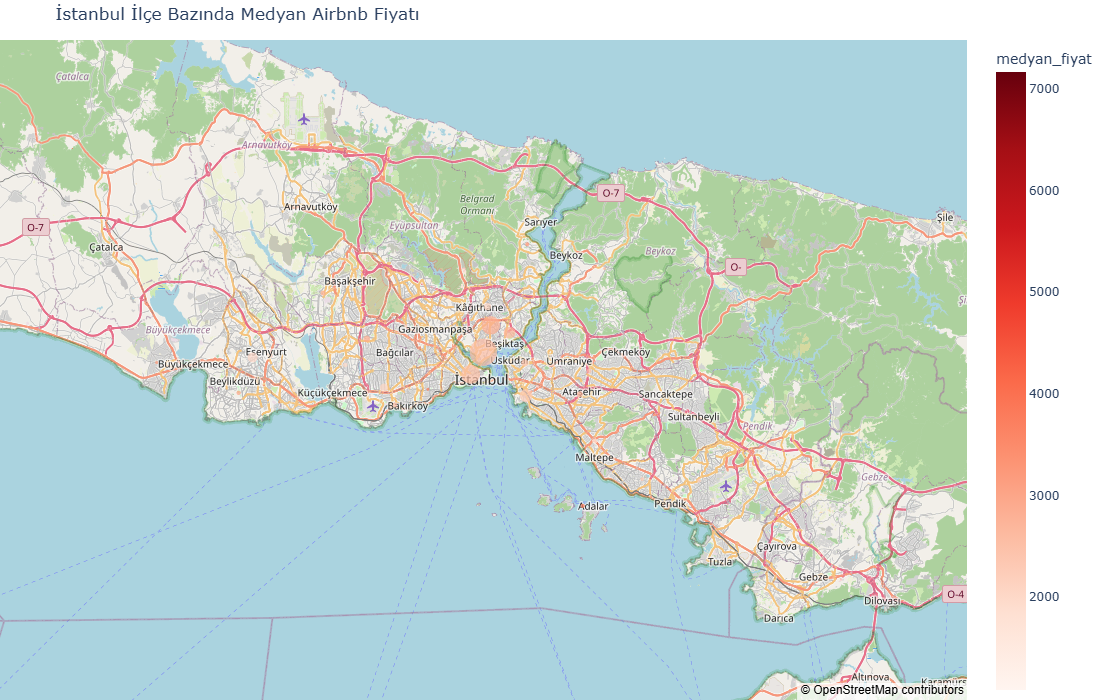

In [159]:
# harita için ilçe bazında özet istatistik
ilce_harita = df.groupby('neighbourhood').agg(
    medyan_fiyat=('price', 'median'),
    ilan_sayisi=('price', 'count'),
    lat=('latitude', 'mean'),
    lon=('longitude', 'mean')
).reset_index()

fig = px.scatter_mapbox(
    ilce_harita,
    lat='lat',
    lon='lon',
    color='medyan_fiyat',
    size='ilan_sayisi',
    color_continuous_scale='Reds',
    mapbox_style='open-street-map',
    zoom=9,
    center={"lat": 41.015, "lon": 28.979},
    title='İstanbul İlçe Bazında Medyan Airbnb Fiyatı',
    hover_name='neighbourhood',
    hover_data={'medyan_fiyat': True, 'ilan_sayisi': True, 'lat': False, 'lon': False}
)

fig.update_layout(
    height=700,
    margin={"r":0,"t":40,"l":0,"b":0}
)

fig.show()